In [7]:
import rasterio

files = [
    "../data_processed/climate/isotermicitat_may_sep_100m.tif",
    "../data_processed/climate/precip_may_sep_100m.tif",
    "../data_processed/climate/temp_seasonality_may_sep_100m.tif"
]

for f in files:
    with rasterio.open(f) as src:
        print("\n---", f)
        print("Shape:", src.shape)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Bounds:", src.bounds)


--- ../data_processed/climate/isotermicitat_may_sep_100m.tif
Shape: (100, 100)
CRS: EPSG:32631
Resolution: (100.0, 100.0)
Bounds: BoundingBox(left=339006.2963960527, bottom=4707594.428744008, right=349006.2963960527, top=4717594.428744008)

--- ../data_processed/climate/precip_may_sep_100m.tif
Shape: (100, 100)
CRS: EPSG:32631
Resolution: (100.0, 100.0)
Bounds: BoundingBox(left=339006.2963960527, bottom=4707594.428744008, right=349006.2963960527, top=4717594.428744008)

--- ../data_processed/climate/temp_seasonality_may_sep_100m.tif
Shape: (100, 100)
CRS: EPSG:32631
Resolution: (100.0, 100.0)
Bounds: BoundingBox(left=339006.2963960527, bottom=4707594.428744008, right=349006.2963960527, top=4717594.428744008)


In [8]:
import numpy as np

for f in files:
    with rasterio.open(f) as src:
        data = src.read(1)
        data = data[~np.isnan(data)]
        
        print("\n---", f)
        print("min:", data.min())
        print("max:", data.max())
        print("mean:", data.mean())


--- ../data_processed/climate/isotermicitat_may_sep_100m.tif
min: 56.65705
max: 61.32245
mean: 59.588543

--- ../data_processed/climate/precip_may_sep_100m.tif
min: 392.93585
max: 554.6664
mean: 474.8146

--- ../data_processed/climate/temp_seasonality_may_sep_100m.tif
min: 27.431002
max: 33.52726
mean: 30.250912


Matplotlib is building the font cache; this may take a moment.


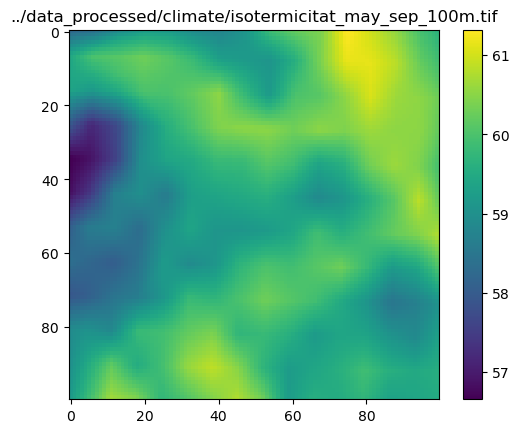

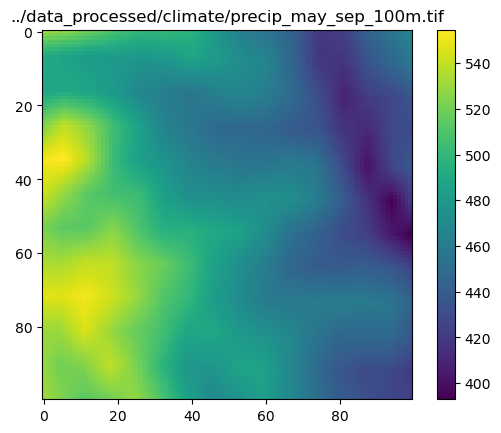

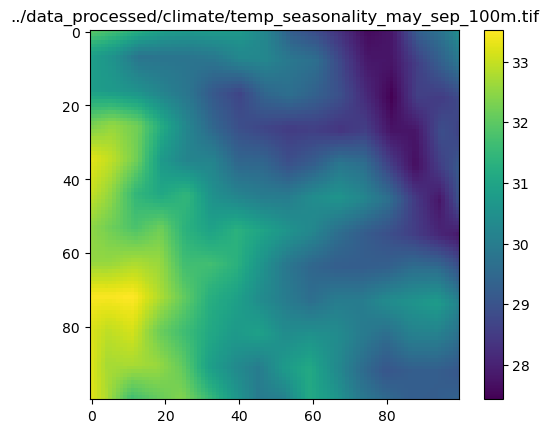

In [9]:
import matplotlib.pyplot as plt

for f in files:
    with rasterio.open(f) as src:
        data = src.read(1)
        
    plt.figure()
    plt.imshow(data)
    plt.colorbar()
    plt.title(f)
    plt.show()

In [10]:
with rasterio.open(files[0]) as src:
    ref_transform = src.transform

for f in files:
    with rasterio.open(f) as src:
        print(f, src.transform == ref_transform)

../data_processed/climate/isotermicitat_may_sep_100m.tif True
../data_processed/climate/precip_may_sep_100m.tif True
../data_processed/climate/temp_seasonality_may_sep_100m.tif True
